In [1]:
## disabeling warning msg
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

# 0 = all messages are logged (default behavior)
# 1 = INFO messages are not printed
# 2 = INFO and WARNING messages are not printed
# 3 = INFO, WARNING, and ERROR messages are not printed
import warnings
warnings.simplefilter('ignore')
import sys
sys.stdout.flush() # resolving tqdm problem


In [2]:
import torch
import numpy as np
from skimage import io, measure

In [3]:
def load_instance_labels(path):
    # label_img: H×W, each nucleus has unique id 1..N
    label_img = io.imread(path)
    return label_img

In [4]:
# def validate_and_fix_boxes(boxes, labels, masks):
#     """
#     Filter invalid boxes AND return corresponding indices for masks.
    
#     Args:
#         boxes: [N, 4] numpy array
#         labels: [N,] numpy array  
#         masks: [N, H, W] numpy array
#     Returns:
#         valid_boxes: filtered boxes
#         valid_labels: filtered labels
#         valid_indices: indices of kept instances (for mask selection)
#     """
#     if len(boxes) == 0:
#         return np.zeros((0, 4)), np.array([]), np.array([])
    
#     # Check width and height
#     widths = boxes[:, 2] - boxes[:, 0]
#     heights = boxes[:, 3] - boxes[:, 1]
    
#     # Valid criteria
#     valid = (widths > 0) & (heights > 0) & (widths < 10000) & (heights < 10000)
    
#     if valid.sum() == 0:
#         return np.zeros((0, 4)), np.array([]), np.array([])
    
#     # Get indices of valid instances
#     valid_indices = np.where(valid)[0]
    
#     valid_boxes = boxes[valid]
#     valid_labels = labels[valid]
    
#     return valid_boxes, valid_labels, valid_indices


In [5]:
def validate_and_fix_boxes(boxes, labels, masks, img_h, img_w):
    """
    Clips boxes to image bounds, filters invalid ones, and returns valid data.
    """
    if len(boxes) == 0:
        return np.zeros((0, 4)), np.array([]), np.array([])
    
    # --- 1. CLAMPING (Crucial Step) ---
    # Ensure coordinates are never outside the image
    # We use np.clip to force values between 0 and width/height
    boxes[:, 0] = np.clip(boxes[:, 0], 0, img_w) # x1
    boxes[:, 1] = np.clip(boxes[:, 1], 0, img_h) # y1
    boxes[:, 2] = np.clip(boxes[:, 2], 0, img_w) # x2
    boxes[:, 3] = np.clip(boxes[:, 3], 0, img_h) # y2

    # --- 2. Calculate Dimensions ---
    widths = boxes[:, 2] - boxes[:, 0]
    heights = boxes[:, 3] - boxes[:, 1]
    
    # --- 3. Filter ---
    # use >= 1.0 to prevent extremely tiny "float dust" boxes (e.g. 0.0001 pixels)
    valid = (widths >= 1.0) & (heights >= 1.0) 
    
    if valid.sum() == 0:
        return np.zeros((0, 4)), np.array([]), np.array([])
    
    # Get indices of valid instances
    valid_indices = np.where(valid)[0]
    
    valid_boxes = boxes[valid]
    valid_labels = labels[valid]
    
    return valid_boxes, valid_labels, valid_indices

In [6]:
def instance_labels_to_masks_and_boxes(label_img, min_area=25):
    """
    Convert instance labels to masks/boxes, filter tiny objects.
    """
    instance_ids = np.unique(label_img)
    instance_ids = instance_ids[instance_ids != 0]

    masks_list = []
    boxes_list = []

    for inst_id in instance_ids:
        mask = (label_img == inst_id)
        area = mask.sum()
        
        # Skip tiny objects (likely noise)
        if area < min_area:
            continue
            
        
        
        # Bounding box
        coords = np.where(mask)
        if len(coords[0]) == 0:
            continue
        y_min, y_max = coords[0].min(), coords[0].max()
        x_min, x_max = coords[1].min(), coords[1].max()
        
        # Ensure valid box
        if x_max > x_min and y_max > y_min:
            boxes_list.append([x_min, y_min, x_max, y_max])
            masks_list.append(mask)

    if len(masks_list) == 0:
        return np.zeros((0, 4)), np.array([]), np.zeros((0, *label_img.shape), dtype=bool)
    
    masks = np.stack(masks_list, axis=0)
    boxes = np.array(boxes_list, dtype=np.float32)
    labels = np.ones((len(masks_list),), dtype=np.int64)
    
    return boxes, labels, masks


In [7]:
def debug_invalid_boxes(label_img_path):
    """Debug single image to find problematic nuclei"""
    label_img = load_instance_labels(label_img_path)
    boxes, labels, masks = instance_labels_to_masks_and_boxes(label_img)
    
    print(f"Found {len(boxes)} candidate nuclei")
    widths = boxes[:, 2] - boxes[:, 0]
    heights = boxes[:, 3] - boxes[:, 1]
    
    invalid = (widths <= 0) | (heights <= 0)
    if invalid.sum() > 0:
        print("Invalid boxes:")
        for i in np.where(invalid)[0]:
            print(f"  Nucleus {i}: box={boxes[i]}, area={masks[i].sum()}")
    
    return boxes, labels, masks

# Run on problematic image
# debug_invalid_boxes("/kaggle/input/nuinsseg/human cerebellum/tissue images/human_cerebellum_1.png")


In [8]:
# debug_invalid_boxes('/kaggle/input/nuinsseg/human salivory gland/tissue images/human_salivory_03.png')

# Preparing Dataset for Masked RCNN

In [9]:
import os
import glob
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as F
from skimage import io
from scipy import ndimage

In [10]:
import os
import torch
import numpy as np
from torch.utils.data import Dataset
from torchvision.transforms import functional as TF
from PIL import Image
import torch.nn.functional as F

import random, os, numpy as np, torch

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print("Seed fixed to 42")


class NuInsSegMaskRCNNDataset(Dataset):
    def __init__(self, image_paths, label_paths, vague_paths, transforms=None):
        # Sanity Check
        assert len(image_paths) == len(label_paths) == len(vague_paths), \
            f"Mismatch: {len(image_paths)} images, {len(label_paths)} labels, {len(vague_paths)} vague masks"
        
        self.image_paths = image_paths
        self.label_paths = label_paths
        self.vague_paths = vague_paths  # Store the list of paths
        self.transforms = transforms
        
        print(f"Dataset initialized with {len(self.image_paths)} samples")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = self.label_paths[idx]
        vague_path = self.vague_paths[idx] # Get specific path for this index
        
        try:
            # 1. Load Image
            img_pil = Image.open(img_path).convert("RGB")
            w, h = img_pil.size
            
            # 2. Load Labels (Your existing logic)
            label_img = load_instance_labels(label_path)
            boxes, labels, masks = instance_labels_to_masks_and_boxes(label_img)
            valid_boxes, valid_labels, valid_indices = validate_and_fix_boxes(
                boxes, labels, masks, h, w
            )
            
            # 3. Load Vague Mask
            # Load as Grayscale (L), convert to numpy
            vague_pil = Image.open(vague_path).convert("L")
            # Resize if necessary to match image (safety check)
            if vague_pil.size != img_pil.size:
                vague_pil = vague_pil.resize(img_pil.size, resample=Image.NEAREST)
            
            vague_np = np.array(vague_pil)
            # Ensure binary (0 or 1)
            vague_tensor = torch.as_tensor((vague_np > 0), dtype=torch.uint8)

            # 4. Prepare Tensor Image
            img_tensor = TF.to_tensor(img_pil)
            
            # 5. Build Target
            if len(valid_boxes) == 0:
                target = self._empty_target(h, w, idx)
            else:
                valid_masks = masks[valid_indices]
                boxes_tensor = torch.as_tensor(valid_boxes, dtype=torch.float32)
                labels_tensor = torch.as_tensor(valid_labels, dtype=torch.int64)
                masks_tensor = torch.as_tensor(valid_masks, dtype=torch.uint8)
                areas = torch.tensor([m.sum() for m in valid_masks], dtype=torch.float32)
                
                target = {
                    "boxes": boxes_tensor,
                    "labels": labels_tensor,
                    "masks": masks_tensor,
                    "image_id": torch.tensor([idx]),
                    "area": areas,
                    "iscrowd": torch.zeros((len(valid_labels),), dtype=torch.int64),
                }

            # --- KEY CHANGE: Add vague mask to target ---
            # Mask R-CNN will ignore keys it doesn't recognize during training,
            # but they will be available in the validation loop.
            target["vague_mask"] = vague_tensor 

            # Apply transforms
            if self.transforms is not None:
                img_tensor, target = self.transforms(img_tensor, target)
            
            return img_tensor, target
            
        except Exception as e:
            print(f"Error loading idx={idx}, path={img_path}: {e}")
            img_tensor = torch.zeros(3, 256, 256, dtype=torch.float32)
            target = self._empty_target(256, 256, idx)
            # Add empty vague mask for fallback
            target["vague_mask"] = torch.zeros((256, 256), dtype=torch.uint8)
            return img_tensor, target

    def _empty_target(self, h, w, idx):
        return {
            "boxes": torch.zeros((0, 4), dtype=torch.float32),
            "labels": torch.zeros((0,), dtype=torch.int64),
            "masks": torch.zeros((0, h, w), dtype=torch.uint8),
            "image_id": torch.tensor([idx]),
            "area": torch.zeros((0,), dtype=torch.float32),
            "iscrowd": torch.zeros((0,), dtype=torch.int64),
        }

Seed fixed to 42


In [11]:
# def vagueness_weighted_mask_loss(mask_loss, pred_masks, gt_masks, vague_mask,
#                                  max_downweight=0.7):
#     """
#     vague_mask: (H,W) in [0,1], 1 = very vague
#     """
#     # Resize vague to mask size
#     H, W = gt_masks.shape[-2:]
#     vague_resized = TF.interpolate(vague_mask[None, None, ...],
#                                   size=(H, W),
#                                   mode="nearest").squeeze(0).squeeze(0)
#     # weight = 1 - alpha * vague
#     weights = 1.0 - max_downweight * vague_resized      # (H,W)
#     weights = weights.clamp(0.3, 1.0)

#     # Re‑compute BCE mask loss with weights
#     # pred_masks: (N_inst, H, W), gt_masks: same
#     bce = F.binary_cross_entropy_with_logits(
#         pred_masks, gt_masks.float(), reduction="none"
#     )  # (N_inst,H,W)
#     weighted = bce * weights.unsqueeze(0)
#     return weighted.mean()


In [12]:
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor

def get_maskrcnn_model(num_classes=2):  # 1 class + background
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(
        weights="DEFAULT"  # pre-trained on COCO
    )

    # Replace box predictor
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # Replace mask predictor
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(
        in_features_mask, hidden_layer, num_classes
    )

    return model


In [13]:
import torch
from torch.utils.data import DataLoader
import torchvision

def collate_fn(batch):
    return tuple(zip(*batch))

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

# from glob import glob
import glob
from sklearn.model_selection import train_test_split

# --- A. Gather Files ---
# Ensure these glob patterns match your actual folder structure
# We use sorted() to guarantee index alignment 0->0, 1->1
all_img_paths = sorted(glob.glob('../input/nuinsseg/*/tissue images/*.png'))
all_label_paths = sorted(glob.glob('../input/nuinsseg/*/label masks modify/*.tif'))
all_vague_paths = sorted(glob.glob('../input/nuinsseg/*/vague areas/mask binary/*.png'))

# --- B. Sanity Check ---
print(f"Images: {len(all_img_paths)}")
print(f"Labels: {len(all_label_paths)}")
print(f"Vague : {len(all_vague_paths)}")

assert len(all_img_paths) == len(all_label_paths) == len(all_vague_paths), \
    "Error: The number of images, labels, and vague masks do not match!"

# Check alignment of first file (Optional but recommended)
print(f"Sample 0 Img:   {os.path.basename(all_img_paths[0])}")
print(f"Sample 0 Vague: {os.path.basename(all_vague_paths[0])}")

# --- C. Create Train/Val Split (3-way split) ---
# We pass all three lists to train_test_split so they are shuffled in sync
train_imgs, val_imgs, train_lbls, val_lbls, train_vague, val_vague = train_test_split(
    all_img_paths, 
    all_label_paths, 
    all_vague_paths,
    test_size=0.2, 
    random_state=42
)

# --- D. Initialize Datasets ---
train_dataset = NuInsSegMaskRCNNDataset(train_imgs, train_lbls, train_vague)
val_dataset   = NuInsSegMaskRCNNDataset(val_imgs, val_lbls, val_vague)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

# --- E. Loaders ---
def collate_fn(batch):
    return tuple(zip(*batch))

train_loader = DataLoader(
    train_dataset, batch_size=2, shuffle=True, collate_fn=collate_fn
)
val_loader = DataLoader(
    val_dataset, batch_size=2, shuffle=False, collate_fn=collate_fn
)

model = get_maskrcnn_model(num_classes=2)
model.to(device)

params = [p for p in model.parameters() if p.requires_grad]
optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 10

Images: 665
Labels: 665
Vague : 665
Sample 0 Img:   human_bladder_01.png
Sample 0 Vague: human_bladder_01.png
Dataset initialized with 532 samples
Dataset initialized with 133 samples
Train size: 532
Val size: 133


Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to /root/.cache/torch/hub/checkpoints/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:09<00:00, 18.0MB/s]


In [14]:
import torch
import torch.nn.functional as F
from torchvision.ops import roi_align
from torchvision.models.detection import roi_heads

# Global variable remains the same
CURRENT_VAGUE_MASKS = None 

def custom_vagueness_mask_loss(mask_logits, proposals, gt_masks, gt_labels, mask_matched_idxs):
    """
    Corrected to handle coordinate scaling between Original Vague Masks and Resized Proposals.
    """
    
    # 1. Prepare Ground Truth Targets (Standard Logic)
    discretization_size = mask_logits.shape[-1]
    gt_mask_targets = roi_heads.project_masks_on_boxes(
        gt_masks, proposals, mask_matched_idxs, discretization_size
    )

    # 2. Select Predicted Class Channel (Standard Logic)
    labels = torch.cat(gt_labels, dim=0) 
    indices = torch.arange(mask_logits.shape[0], device=mask_logits.device)
    pred_masks_selected = mask_logits[indices, labels]

    # 3. Prepare Vague Masks (The CORRECTION)
    # ---------------------------------------
    global CURRENT_VAGUE_MASKS
    
    if CURRENT_VAGUE_MASKS is not None:
        vague_crops_list = []
        
        # We must process each image individually because the scale might differ
        # per image (Mask R-CNN supports multi-scale training)
        for i in range(len(proposals)):
            
            # A. Get Shapes to calculate Scale
            # gt_masks[i] is already resized by the model (e.g., 800x800)
            # vague_mask is original size (e.g., 512x512)
            
            # Handle empty ground truth case (rare but possible)
            if gt_masks[i].numel() == 0:
                 # If no GT, we can't infer scale, but we also have no loss to compute usually
                 # Just make a dummy crop
                 dummy_crop = torch.zeros((proposals[i].shape[0], 1, 28, 28), device=mask_logits.device)
                 vague_crops_list.append(dummy_crop)
                 continue

            h_resized, w_resized = gt_masks[i].shape[-2:]
            h_orig, w_orig = CURRENT_VAGUE_MASKS[i].shape[-2:]
            
            # Calculate Scale: "How much do I shrink the 800px box to fit the 512px mask?"
            # scale = Original / Resized
            scale = h_orig / h_resized
            
            # B. Prepare Vague Mask for this image
            # Shape: (1, 1, H_orig, W_orig)
            vague_img = CURRENT_VAGUE_MASKS[i].unsqueeze(0).unsqueeze(0).float()
            
            # C. Run RoIAlign with the correct scale
            # This maps the 800px proposal boxes onto the 512px vague mask perfectly
            crop = roi_align(
                vague_img,
                [proposals[i]], # box for just this image
                output_size=(discretization_size, discretization_size),
                spatial_scale=scale, 
                sampling_ratio=-1
            )
            vague_crops_list.append(crop)
        
        # Concatenate all crops from the batch
        if len(vague_crops_list) > 0:
            vague_crops = torch.cat(vague_crops_list, dim=0).squeeze(1) # (N_total, 28, 28)
        else:
            vague_crops = torch.zeros_like(pred_masks_selected)

        # 4. Calculate Weighted Loss
        # --------------------------
        loss = F.binary_cross_entropy_with_logits(
            pred_masks_selected, gt_mask_targets, reduction="none"
        )
        
        # Weighting Logic
        # Vague regions (1.0) get low weight (0.1)
        # Clear regions (0.0) get high weight (1.0)
        weights = 1.0 - (vague_crops * 0.3)
        
        weighted_loss = (loss * weights).mean()
        return weighted_loss

    else:
        return F.binary_cross_entropy_with_logits(
            pred_masks_selected, gt_mask_targets
        )

# --- RE-APPLY THE PATCH ---
print("Overriding mask_rcnn_loss with SCALING CORRECTION...")
roi_heads.mask_rcnn_loss = custom_vagueness_mask_loss

Overriding mask_rcnn_loss with SCALING CORRECTION...


In [15]:
# import torch
# import numpy as np
# import cv2  # OpenCV for resizing
# from tqdm.auto import tqdm

# # --- Improved Dice Helper ---
# def compute_dice_score(pred_mask, gt_mask):
#     """
#     Computes Dice score, handling shape mismatches automatically.
#     """
#     # 1. Check for Shape Mismatch and Resize if needed
#     if pred_mask.shape != gt_mask.shape:
#         # We always resize Prediction to match Ground Truth (to evaluate against reality)
#         # using Nearest Neighbor interpolation (since masks are binary 0/1)
#         h, w = gt_mask.shape
#         pred_mask = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        
#     # 2. Flatten and Compute
#     pred_flat = pred_mask.flatten()
#     gt_flat = gt_mask.flatten()
    
#     intersection = np.sum(pred_flat * gt_flat)
#     return (2. * intersection) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)

# # --- Main Evaluation Loop ---
# dice_scores = []
# model.eval()
# device = next(model.parameters()).device

# print("Starting robust evaluation...")
# loader_bar = tqdm(val_loader, desc="Evaluating", unit="batch")

# with torch.no_grad():
#     for images, targets in loader_bar:
#         images = [img.to(device) for img in images]
#         outputs = model(images)

#         for i, out in enumerate(outputs):
#             # --- 1. Process Prediction ---
#             scores = out["scores"].cpu().numpy()
            
#             # Filter low confidence predictions
#             keep_idx = scores > 0.5 
#             pred_masks_raw = out["masks"][keep_idx] # [K, 1, H, W]
            
#             # Combine instances into one semantic map (2D)
#             if len(pred_masks_raw) > 0:
#                 pred_masks_np = pred_masks_raw.squeeze(1).cpu().numpy()
#                 # Max projection to combine instances
#                 combined_pred = np.max(pred_masks_np, axis=0)
#                 # Binarize (0 or 1)
#                 combined_pred = (combined_pred > 0.5).astype(np.uint8)
#             else:
#                 # Handle empty detection case
#                 # We use the shape of the FIRST image channel to guess dimensions 
#                 # or fallback to 256x256 if needed.
#                 # However, the compute_dice_score will handle the resize anyway.
#                 # Let's create a placeholder based on input image size
#                 img_h, img_w = images[i].shape[-2:] 
#                 combined_pred = np.zeros((img_h, img_w), dtype=np.uint8)

#             # --- 2. Process Ground Truth ---
#             gt_masks_raw = targets[i]["masks"].cpu().numpy()
            
#             if len(gt_masks_raw) > 0:
#                 combined_gt = np.max(gt_masks_raw, axis=0).astype(np.uint8)
#             else:
#                 # Create empty mask with same size as prediction to avoid errors
#                 combined_gt = np.zeros_like(combined_pred)

#             # --- 3. Compute Dice with Safety Check ---
#             d = compute_dice_score(combined_pred, combined_gt)
#             dice_scores.append(d)
            
#             # Update bar
#             loader_bar.set_postfix(MeanDice=np.mean(dice_scores))

# print(f"\nFinal Mean Dice Score: {np.mean(dice_scores):.4f}")

In [16]:
# for epoch in range(1):
#     model.train()
#     total_loss = 0.0
#     skipped_images = 0
    
#     for batch_idx, (images, targets) in enumerate(train_loader):
#         images = [img.to(device) for img in images]
        
#         # Validate targets before moving to GPU
#         valid_targets = []
#         for target in targets:
#             if len(target["boxes"]) > 0 and (target["boxes"][:, 3] - target["boxes"][:, 1]).min() > 0:
#                 valid_targets.append({k: v.to(device) for k, v in target.items()})
#             else:
#                 skipped_images += 1
        
#         if len(valid_targets) == 0:
#             continue
            
#         targets = valid_targets


#         vague_list = [t["vague_mask"].to(device).unsqueeze(0) for t in targets] # (1, H, W)
    
#     # UPDATE THE GLOBAL VARIABLE HERE
#         CURRENT_VAGUE_MASKS = vague_list 
    
#         # 2. Standard Training Steps (No other changes needed!)
#         # -----------------------------------------------------
#         targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
        
#         # The model calls roi_heads, which calls mask_rcnn_loss, 
#         # which now reads CURRENT_VAGUE_MASKS!
#         loss_dict = model(images, targets)
#         # loss_dict = model(images[:len(targets)], targets)  # Match image/target lengths
#         losses = sum(loss for loss in loss_dict.values())

#         # mask_logits = model.roi_heads.mask_logits  # (K,C,H,W) or (K,1,H,W)
#         # # Build per‑image gt mask tensor concatenated in same order as training collate
#         # gt_masks = torch.cat([t["masks"].to(device) for t in targets], dim=0)
    
#         # vague_full = torch.stack([t["vague_mask"].to(device) for t in targets], dim=0)
#         # vague_full = vague_full  # (B,H,W) – you can tile per instance if needed
    
#         # # Example: simple global vague weighting (same for all instances in image i)
#         # # For more exact mapping, track ROI→image index from roi_heads.
#         # vague_img = vague_full[0]  # if batch=1; extend for batch>1
    
#         # new_mask_loss = vagueness_weighted_mask_loss(
#         #     loss_dict["loss_mask"], mask_logits.squeeze(1), gt_masks, vague_img
#         # )
    
#         # loss = (loss
#         #         - loss_dict["loss_mask"]
#         #         + new_mask_loss)

#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()

#         total_loss += losses.item()
        
#         # if batch_idx % 10 == 0:
#         #     print(f"Batch {batch_idx}, valid_targets={len(valid_targets)}/{len(targets)}")
    
#     print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}, skipped={skipped_images}")


In [17]:
def train_one_epoch_with_vague(model, optimizer, train_loader, val_loader, device, epoch, num_epochs):
    global CURRENT_VAGUE_MASKS

    model.train()
    total_loss = 0.0

    for batch_idx, (images, targets) in enumerate(train_loader):
        # Move images to device
        images = [img.to(device) for img in images]

        # Move targets to device, and collect vague masks
        vaguelist = []
        targets_device = []
        for t in targets:
            td = {k: v.to(device) for k, v in t.items()}
            vaguelist.append(td["vague_mask"].unsqueeze(0))  # (1,H,W) per image
            td.pop("vague_mask")  # keep target keys standard for Mask R‑CNN
            targets_device.append(td)

        CURRENT_VAGUE_MASKS = vaguelist  # list of (1,H,W) tensors

        loss_dict = model(images, targets_device)
        losses = sum(loss for loss in loss_dict.values())

        optimizer.zero_grad()
        losses.backward()
        optimizer.step()

        total_loss += losses.item()

        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1} Batch {batch_idx} Loss {losses.item():.4f}")

        CURRENT_VAGUE_MASKS = None  # reset after each batch

    avg_train_loss = total_loss / len(train_loader)

    # ----- validation Dice -----
    mean_dice = evaluate_dice_only(model, val_loader, device)

    print(f"Epoch {epoch+1}: Avg Train Loss {avg_train_loss:.4f}, Val Dice {mean_dice:.4f}")
    return avg_train_loss, mean_dice


In [18]:
import numpy as np
import cv2
from tqdm.auto import tqdm

def compute_dice_score(pred_mask, gt_mask):
    if pred_mask.shape != gt_mask.shape:
        h, w = gt_mask.shape
        pred_mask = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    inter = np.sum(pred_flat & gt_flat)
    return 2.0 * inter / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)

def evaluate_dice_only(model, val_loader, device):
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for images, targets in tqdm(val_loader, desc="Val Dice", unit="batch"):
            images = [img.to(device) for img in images]
            outputs = model(images)

            for i, out in enumerate(outputs):
                scores = out["scores"].cpu().numpy()
                keep = scores > 0.5
                pred_raw = out["masks"][keep]  # K,1,H,W

                if len(pred_raw) > 0:
                    pred_np = pred_raw.squeeze(1).cpu().numpy()
                    combined_pred = np.max(pred_np, axis=0)
                    combined_pred = (combined_pred > 0.5).astype(np.uint8)
                else:
                    H, W = images[i].shape[-2:]
                    combined_pred = np.zeros((H, W), dtype=np.uint8)

                gt_raw = targets[i]["masks"].cpu().numpy().astype(np.uint8)
                if len(gt_raw) > 0:
                    combined_gt = np.max(gt_raw, axis=0).astype(np.uint8)
                else:
                    combined_gt = np.zeros_like(combined_pred)

                d = compute_dice_score(combined_pred, combined_gt)
                dice_scores.append(d)

    mean_dice = float(np.mean(dice_scores)) if dice_scores else 0.0
    return mean_dice


In [19]:
optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=0.005,
    momentum=0.9,
    weight_decay=0.0005,
)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

num_epochs = 30
history = {"loss": [], "dice": []}

for epoch in range(num_epochs):
    train_loss, val_dice = train_one_epoch_with_vague(
        model, optimizer, train_loader, val_loader, device, epoch, num_epochs
    )
    history["loss"].append(train_loss)
    history["dice"].append(val_dice)

    scheduler.step()

print("Training done.")
print("Per‑epoch Dice:", history["dice"])


Epoch 1 Batch 0 Loss 6.0406
Epoch 1 Batch 10 Loss 1.8679
Epoch 1 Batch 20 Loss 1.2992
Epoch 1 Batch 30 Loss 1.8417
Epoch 1 Batch 40 Loss 1.3137
Epoch 1 Batch 50 Loss 0.7389
Epoch 1 Batch 60 Loss 0.9527
Epoch 1 Batch 70 Loss 1.3393
Epoch 1 Batch 80 Loss 1.2276
Epoch 1 Batch 90 Loss 1.3677
Epoch 1 Batch 100 Loss 1.2636
Epoch 1 Batch 110 Loss 1.3827
Epoch 1 Batch 120 Loss 0.9354
Epoch 1 Batch 130 Loss 1.3445
Epoch 1 Batch 140 Loss 1.3368
Epoch 1 Batch 150 Loss 1.1829
Epoch 1 Batch 160 Loss 1.0087
Epoch 1 Batch 170 Loss 1.0354
Epoch 1 Batch 180 Loss 1.6263
Epoch 1 Batch 190 Loss 0.7986
Epoch 1 Batch 200 Loss 1.2291
Epoch 1 Batch 210 Loss 1.2855
Epoch 1 Batch 220 Loss 1.0255
Epoch 1 Batch 230 Loss 1.7807
Epoch 1 Batch 240 Loss 1.4737
Epoch 1 Batch 250 Loss 1.4141
Epoch 1 Batch 260 Loss 1.4892


Val Dice:   0%|          | 0/67 [00:00<?, ?batch/s]

Epoch 1: Avg Train Loss 1.3476, Val Dice 0.7373
Epoch 2 Batch 0 Loss 0.8777
Epoch 2 Batch 10 Loss 1.2716
Epoch 2 Batch 20 Loss 1.5934
Epoch 2 Batch 30 Loss 1.1501
Epoch 2 Batch 40 Loss 0.9686
Epoch 2 Batch 50 Loss 0.8952
Epoch 2 Batch 60 Loss 1.3623
Epoch 2 Batch 70 Loss 1.2263
Epoch 2 Batch 80 Loss 1.3648
Epoch 2 Batch 90 Loss 1.1012
Epoch 2 Batch 100 Loss 1.0820
Epoch 2 Batch 110 Loss 0.8166
Epoch 2 Batch 120 Loss 1.2472
Epoch 2 Batch 130 Loss 0.7791
Epoch 2 Batch 140 Loss 0.7862
Epoch 2 Batch 150 Loss 1.0216
Epoch 2 Batch 160 Loss 1.2563
Epoch 2 Batch 170 Loss 0.9069
Epoch 2 Batch 180 Loss 1.3258
Epoch 2 Batch 190 Loss 0.9473
Epoch 2 Batch 200 Loss 1.0907
Epoch 2 Batch 210 Loss 1.0785
Epoch 2 Batch 220 Loss 1.3401
Epoch 2 Batch 230 Loss 0.9092
Epoch 2 Batch 240 Loss 1.0294
Epoch 2 Batch 250 Loss 1.2173
Epoch 2 Batch 260 Loss 1.1063


Val Dice:   0%|          | 0/67 [00:00<?, ?batch/s]

Epoch 2: Avg Train Loss 1.1741, Val Dice 0.7691
Epoch 3 Batch 0 Loss 1.2595
Epoch 3 Batch 10 Loss 1.0632
Epoch 3 Batch 20 Loss 1.0332
Epoch 3 Batch 30 Loss 0.8362
Epoch 3 Batch 40 Loss 1.3408
Epoch 3 Batch 50 Loss 1.1415
Epoch 3 Batch 60 Loss 1.2491
Epoch 3 Batch 70 Loss 0.9741
Epoch 3 Batch 80 Loss 1.0695
Epoch 3 Batch 90 Loss 1.2468
Epoch 3 Batch 100 Loss 1.0746
Epoch 3 Batch 110 Loss 1.2914
Epoch 3 Batch 120 Loss 0.9690
Epoch 3 Batch 130 Loss 0.8745
Epoch 3 Batch 140 Loss 0.9739
Epoch 3 Batch 150 Loss 0.5975
Epoch 3 Batch 160 Loss 1.1625
Epoch 3 Batch 170 Loss 1.1222
Epoch 3 Batch 180 Loss 1.2569
Epoch 3 Batch 190 Loss 0.8173
Epoch 3 Batch 200 Loss 1.1086
Epoch 3 Batch 210 Loss 1.0402
Epoch 3 Batch 220 Loss 1.0000
Epoch 3 Batch 230 Loss 1.2287
Epoch 3 Batch 240 Loss 1.2163
Epoch 3 Batch 250 Loss 1.4872
Epoch 3 Batch 260 Loss 1.1562


...

Epoch 28: Avg Train Loss 0.8278, Val Dice 0.8083
Epoch 29 Batch 0 Loss 0.8944
Epoch 29 Batch 10 Loss 0.9127
Epoch 29 Batch 20 Loss 0.8293
Epoch 29 Batch 30 Loss 0.6404
Epoch 29 Batch 40 Loss 1.1032
Epoch 29 Batch 50 Loss 0.9532
Epoch 29 Batch 60 Loss 0.6963
Epoch 29 Batch 70 Loss 0.7431
Epoch 29 Batch 80 Loss 0.9281
Epoch 29 Batch 90 Loss 1.0257
Epoch 29 Batch 100 Loss 0.7177
Epoch 29 Batch 110 Loss 0.7171
Epoch 29 Batch 120 Loss 0.7728
Epoch 29 Batch 130 Loss 0.9520
Epoch 29 Batch 140 Loss 0.8717
Epoch 29 Batch 150 Loss 0.8925
Epoch 29 Batch 160 Loss 0.7923
Epoch 29 Batch 170 Loss 0.9099
Epoch 29 Batch 180 Loss 0.8724
Epoch 29 Batch 190 Loss 0.8974
Epoch 29 Batch 200 Loss 0.6392
Epoch 29 Batch 210 Loss 0.4246
Epoch 29 Batch 220 Loss 0.8480
Epoch 29 Batch 230 Loss 0.7908
Epoch 29 Batch 240 Loss 0.6007
Epoch 29 Batch 250 Loss 0.6442
Epoch 29 Batch 260 Loss 0.9490


Val Dice:   0%|          | 0/67 [00:00<?, ?batch/s]

Epoch 29: Avg Train Loss 0.8248, Val Dice 0.8082
Epoch 30 Batch 0 Loss 1.1275
Epoch 30 Batch 10 Loss 1.2006
Epoch 30 Batch 20 Loss 0.7047
Epoch 30 Batch 30 Loss 0.4870
Epoch 30 Batch 40 Loss 1.0034
Epoch 30 Batch 50 Loss 0.9511
Epoch 30 Batch 60 Loss 0.9078
Epoch 30 Batch 70 Loss 0.8680
Epoch 30 Batch 80 Loss 0.8465
Epoch 30 Batch 90 Loss 0.8619
Epoch 30 Batch 100 Loss 0.7762
Epoch 30 Batch 110 Loss 0.6327
Epoch 30 Batch 120 Loss 0.8350
Epoch 30 Batch 130 Loss 0.7350
Epoch 30 Batch 140 Loss 0.9246
Epoch 30 Batch 150 Loss 0.7812
Epoch 30 Batch 160 Loss 0.6863
Epoch 30 Batch 170 Loss 1.1287
Epoch 30 Batch 180 Loss 0.8278
Epoch 30 Batch 190 Loss 0.7719
Epoch 30 Batch 200 Loss 0.7594
Epoch 30 Batch 210 Loss 0.8249
Epoch 30 Batch 220 Loss 1.1398
Epoch 30 Batch 230 Loss 0.9196
Epoch 30 Batch 240 Loss 0.6517
Epoch 30 Batch 250 Loss 0.6766
Epoch 30 Batch 260 Loss 0.6406


Val Dice:   0%|          | 0/67 [00:00<?, ?batch/s]

Epoch 30: Avg Train Loss 0.8246, Val Dice 0.8082
Training done.
Per‑epoch Dice: [0.7372952561770175, 0.7690947006267973, 0.7949575721486736, 0.7957013077974573, 0.792573364939945, 0.8053381126796945, 0.8054443319537434, 0.8086983157729273, 0.8072614687505542, 0.8071116106340402, 0.8085397854013519, 0.8087798118120676, 0.8081983869076773, 0.8083819905518332, 0.80822887244289, 0.8084523852725689, 0.8083104651539872, 0.8083241788208376, 0.8081919454217786, 0.8081801440028513, 0.8081683833006776, 0.8081367131528432, 0.8081405680250786, 0.8081507723208903, 0.8082501266682602, 0.8082264035509766, 0.8082268904249348, 0.8082515818161063, 0.808227048297739, 0.8082267264483823]


In [20]:
# # --- ASSUMPTION: You have already run the "Monkey Patch" code block ---
# # if not, scroll up to my previous response and run that cell first!

# model.train()
# # Initialize the optimizer (ensure this is done)
# optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9, weight_decay=0.0005)

# for epoch in range(num_epochs):
#     total_loss = 0
    
#     for batch_idx, (images, targets) in enumerate(train_loader):
#         images = [img.to(device) for img in images]
        
#         # 1. Update the Global Variable with Vague Masks
#         # The patched loss function inside the model will read this!
#         vague_list = [t["vague_mask"].to(device).unsqueeze(0) for t in targets]
#         CURRENT_VAGUE_MASKS = vague_list 

#         # 2. Move targets to device
#         targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

#         # 3. Forward Pass
#         # The model now AUTOMATICALLY uses your custom vague loss
#         loss_dict = model(images, targets)
        
#         # 4. Sum Losses
#         losses = sum(loss for loss in loss_dict.values())

#         # --- DELETED LINES: No need to get mask_logits or calculate new_mask_loss manually ---

#         # 5. Backprop
#         optimizer.zero_grad()
#         losses.backward()
#         optimizer.step()
        
#         total_loss += losses.item()
        
#         # Cleanup global variable
#         CURRENT_VAGUE_MASKS = None
        
#         # if batch_idx % 10 == 0:
#             # print(f"Batch {batch_idx}: Loss {losses.item():.4f}")

#     print(f"Epoch {epoch+1}: Avg Loss={total_loss/len(train_loader):.4f}")

In [21]:
# Create a directory for models if it doesn't exist
import os
os.makedirs("models", exist_ok=True)

save_path = "models/maskrcnn_w_vague_nuinsseg_10eopchs.pth"
torch.save(model.state_dict(), save_path)
print(f"Model weights saved to {save_path}")



Model weights saved to models/maskrcnn_w_vague_nuinsseg_10eopchs.pth


In [22]:
# import os

In [23]:
# ##Already Saved in previous run
# ##16-20 epochs enough

# model.load_state_dict(torch.load('/kaggle/input/maskrcnn-nuinsseg/pytorch/10epcohs/1/maskrcnn_nuinsseg_best_10epochs.pth'))

# model.eval()
# model.to(device)
# print("Loaded Model")

In [24]:
import torch
import numpy as np
import cv2  # OpenCV for resizing
from tqdm.auto import tqdm

import numpy as np
import cv2
from scipy.optimize import linear_sum_assignment # Optional, but recommended for strict matching

# --- 1. Robust IoU Helper ---
def compute_iou_batch(masks1, masks2):
    """
    Computes IoU matrix between Ground Truth (masks1) and Preds (masks2).
    """
    if masks1.size == 0 or masks2.size == 0:
        return np.zeros((len(masks1), len(masks2))), None, None
        
    # Flatten spatial dims: [N, H*W] and [M, H*W]
    m1 = masks1.reshape(masks1.shape[0], -1)
    m2 = masks2.reshape(masks2.shape[0], -1)
    
    # --- CRITICAL FIX HERE ---
    # Use float32 to prevent overflow during matrix multiplication!
    # (uint8 overflows at 255, so an overlap of 300 pixels becomes 44)
    intersection = np.matmul(m1.astype(np.float32), m2.astype(np.float32).T)
    
    # Calculate Areas
    area1 = m1.sum(axis=1)[:, None] # [N, 1]
    area2 = m2.sum(axis=1)[None, :] # [1, M]
    
    union = area1 + area2 - intersection
    
    # Avoid division by zero
    iou = intersection / (union + 1e-6)
    return iou, intersection, union

# --- 2. Corrected AJI & PQ Helper ---
def compute_aji_pq_instance(pred_masks, gt_masks):
    # 1. Resize Preds if needed
    if len(pred_masks) > 0 and len(gt_masks) > 0:
        if pred_masks[0].shape != gt_masks[0].shape:
            h, w = gt_masks[0].shape
            pred_masks = np.array([
                cv2.resize(m.astype(np.uint8), (w, h), interpolation=cv2.INTER_NEAREST) 
                for m in pred_masks
            ])

    # 2. Handle Empty Cases
    if len(gt_masks) == 0:
        return (0.0, 0.0) if len(pred_masks) > 0 else (1.0, 1.0)
    if len(pred_masks) == 0:
        return 0.0, 0.0

    # 3. Get IoU Matrix
    iou_matrix, intersect_matrix, union_matrix = compute_iou_batch(gt_masks, pred_masks)
    
    # --- AJI Calculation (Greedy Matching) ---
    overall_inter = 0
    overall_union = 0
    
    # Track which predictions have been used to prevent "Double Counting"
    pred_used = np.zeros(len(pred_masks), dtype=bool)
    gt_used = np.zeros(len(gt_masks), dtype=bool)

    # Iterate over GTs to find best matches
    # (A strict implementation might use Hungarian matching here, but Greedy is common for AJI)
    for i in range(len(gt_masks)):
        # Find best match for this GT
        best_pred_idx = np.argmax(iou_matrix[i])
        best_iou = iou_matrix[i, best_pred_idx]
        
        # Condition: Match must be > 0 and Pred must not be already taken by another GT
        if best_iou > 0 and not pred_used[best_pred_idx]:
            overall_inter += intersect_matrix[i, best_pred_idx]
            overall_union += union_matrix[i, best_pred_idx]
            pred_used[best_pred_idx] = True
            gt_used[i] = True
        else:
            # GT is unmatched, add its area to Union
            overall_union += gt_masks[i].sum()
            
    # Add all UNMATCHED predictions to the Union
    # (This penalizes False Positives)
    unused_preds_indices = np.where(~pred_used)[0]
    for idx in unused_preds_indices:
        overall_union += pred_masks[idx].sum()
        
    aji = overall_inter / (overall_union + 1e-6)

    # --- PQ Calculation (Standard) ---
    # PQ requires unique 1-to-1 matching with IoU > 0.5
    tp = 0
    iou_sum = 0
    
    # Reset usage flags for PQ (it has a stricter threshold)
    pred_used_pq = np.zeros(len(pred_masks), dtype=bool)
    
    for i in range(len(gt_masks)):
        best_pred_idx = np.argmax(iou_matrix[i])
        best_iou = iou_matrix[i, best_pred_idx]
        
        if best_iou > 0.5 and not pred_used_pq[best_pred_idx]:
            tp += 1
            iou_sum += best_iou
            pred_used_pq[best_pred_idx] = True

    # FP: Predictions that were not matched to any GT
    fp = len(pred_masks) - tp
    # FN: GTs that were not matched to any Pred
    fn = len(gt_masks) - tp
    
    sq = iou_sum / (tp + 1e-6)
    rq = tp / (tp + 0.5 * fp + 0.5 * fn + 1e-6)
    pq = sq * rq
    
    return aji, pq

# --- 2. Dice Helper (Your Improved Version) ---
def compute_dice_score(pred_mask, gt_mask):
    # 1. Check for Shape Mismatch and Resize
    if pred_mask.shape != gt_mask.shape:
        h, w = gt_mask.shape
        pred_mask = cv2.resize(pred_mask, (w, h), interpolation=cv2.INTER_NEAREST)
        
    # 2. Flatten and Compute
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    intersection = np.sum(pred_flat * gt_flat)
    return (2. * intersection) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)



# --- Main Evaluation Loop ---
dice_scores = []
aji_scores = []
pq_scores = []

model.eval()
device = next(model.parameters()).device

print("Starting robust evaluation with Dice, AJI, and PQ...")
loader_bar = tqdm(val_loader, desc="Evaluating", unit="batch")

with torch.no_grad():
    for images, targets in loader_bar:
        images = [img.to(device) for img in images]
        outputs = model(images)

        for i, out in enumerate(outputs):
            # --- 1. Process Prediction ---
            scores = out["scores"].cpu().numpy()
            keep_idx = scores > 0.5
            
            # Get Instance Masks (needed for AJI/PQ)
            pred_masks_raw = out["masks"][keep_idx]
            
            if len(pred_masks_raw) > 0:
                # [N, 1, H, W] -> [N, H, W]
                pred_masks_np = pred_masks_raw.squeeze(1).cpu().numpy()
                pred_masks_np = (pred_masks_np > 0.5).astype(np.uint8)
                
                # Combine for Dice (Semantic)
                combined_pred = np.max(pred_masks_np, axis=0)
            else:
                # SAFETY FIX: Create an empty array with correct (0, H, W) shape
                img_h, img_w = images[i].shape[-2:] 
                pred_masks_np = np.zeros((0, img_h, img_w), dtype=np.uint8)
                
                # Placeholder for Dice
                combined_pred = np.zeros((img_h, img_w), dtype=np.uint8)

            # --- 2. Process Ground Truth ---
            gt_masks_raw = targets[i]["masks"].cpu().numpy().astype(np.uint8)
            
            if len(gt_masks_raw) > 0:
                combined_gt = np.max(gt_masks_raw, axis=0).astype(np.uint8)
            else:
                combined_gt = np.zeros_like(combined_pred)

            # --- 3. Compute Metrics ---
            
            # A. Dice (Semantic)
            # (Your function handles resizing internally)
            d = compute_dice_score(combined_pred, combined_gt)
            dice_scores.append(d)
            
            # B. AJI & PQ (Instance)
            # (My function handles resizing internally)
            aji, pq = compute_aji_pq_instance(pred_masks_np, gt_masks_raw)
            aji_scores.append(aji)
            pq_scores.append(pq)
            
            # Update bar
            loader_bar.set_postfix(
                Dice=f"{np.mean(dice_scores):.3f}", 
                AJI=f"{np.mean(aji_scores):.3f}",
                PQ=f"{np.mean(pq_scores):.3f}"
            )

print("\n" + "="*30)
print(f"Final Mean Dice: {np.mean(dice_scores):.4f}")
print(f"Final Mean AJI:  {np.mean(aji_scores):.4f}")
print(f"Final Mean PQ:   {np.mean(pq_scores):.4f}")
print("="*30)

Starting robust evaluation with Dice, AJI, and PQ...


Evaluating:   0%|          | 0/67 [00:00<?, ?batch/s]


Final Mean Dice: 0.8082
Final Mean AJI:  0.5991
Final Mean PQ:   0.6101


In [25]:
# evaluate_model(model, val_loader)

In [26]:
# import matplotlib.pyplot as plt
# import numpy as np
# import torch

# def compute_dice_score(pred_mask, gt_mask):
#     # Flatten
#     pred_flat = pred_mask.flatten()
#     gt_flat = gt_mask.flatten()
#     intersection = np.sum(pred_flat * gt_flat)
#     return (2. * intersection) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)

# dice_scores = []
# num_shown = 0  # Counter to limit visualization

# model.eval()
# with torch.no_grad():
#     for images, targets in val_loader:
#         # Move images to device
#         images_device = [img.to(device) for img in images]
#         outputs = model(images_device)

#         for i, out in enumerate(outputs):
#             # --- 1. Process Prediction ---
#             # Threshold soft masks to binary (0 or 1)
#             pred_masks = out["masks"] > 0.5  # [N, 1, H, W]
#             pred_masks = pred_masks.squeeze(1).cpu().numpy()
            
#             # Combine all instances into one semantic map (using max projection)
#             if len(pred_masks) > 0:
#                 combined_pred = np.max(pred_masks, axis=0).astype(np.uint8)
#             else:
#                 # Handle case where model detects nothing
#                 combined_pred = np.zeros((images[i].shape[1], images[i].shape[2]), dtype=np.uint8)
            
#             # --- 2. Process Ground Truth ---
#             gt_masks = targets[i]["masks"].cpu().numpy() # [N, H, W]
#             # Combine instances into one map
#             if len(gt_masks) > 0:
#                 combined_gt = np.max(gt_masks, axis=0).astype(np.uint8)
#             else:
#                 combined_gt = np.zeros_like(combined_pred)

#             # --- 3. Calculate Dice ---
#             d = compute_dice_score(combined_pred, combined_gt)
#             dice_scores.append(d)
            
#             # --- 4. Visualization (Limit to first 5 images) ---
#             if num_shown < 5:
#                 # Prepare Image for plotting (C, H, W) -> (H, W, C)
#                 # Note: We use images[i] (CPU tensor) not images_device[i]
#                 img_display = images[i].permute(1, 2, 0).numpy()
                
#                 # Normalize if necessary (if your transforms normalized to not 0-1)
#                 # img_display = (img_display - img_display.min()) / (img_display.max() - img_display.min())

#                 fig, axes = plt.subplots(1, 3, figsize=(12, 4))
                
#                 # Plot Original Image
#                 axes[0].imshow(img_display)
#                 axes[0].set_title(f"Image {num_shown+1}")
#                 axes[0].axis('off')
                
#                 # Plot Ground Truth
#                 axes[1].imshow(combined_gt, cmap='nipy_spectral')
#                 axes[1].set_title("Ground Truth Mask")
#                 axes[1].axis('off')
                
#                 # Plot Prediction
#                 axes[2].imshow(combined_pred, cmap='nipy_spectral')
#                 axes[2].set_title(f"Prediction (Dice: {d:.2f})")
#                 axes[2].axis('off')
                
#                 plt.tight_layout()
#                 plt.show()
                
#                 num_shown += 1

# print(f"\nOverall Mean Dice Score: {np.mean(dice_scores):.4f}")

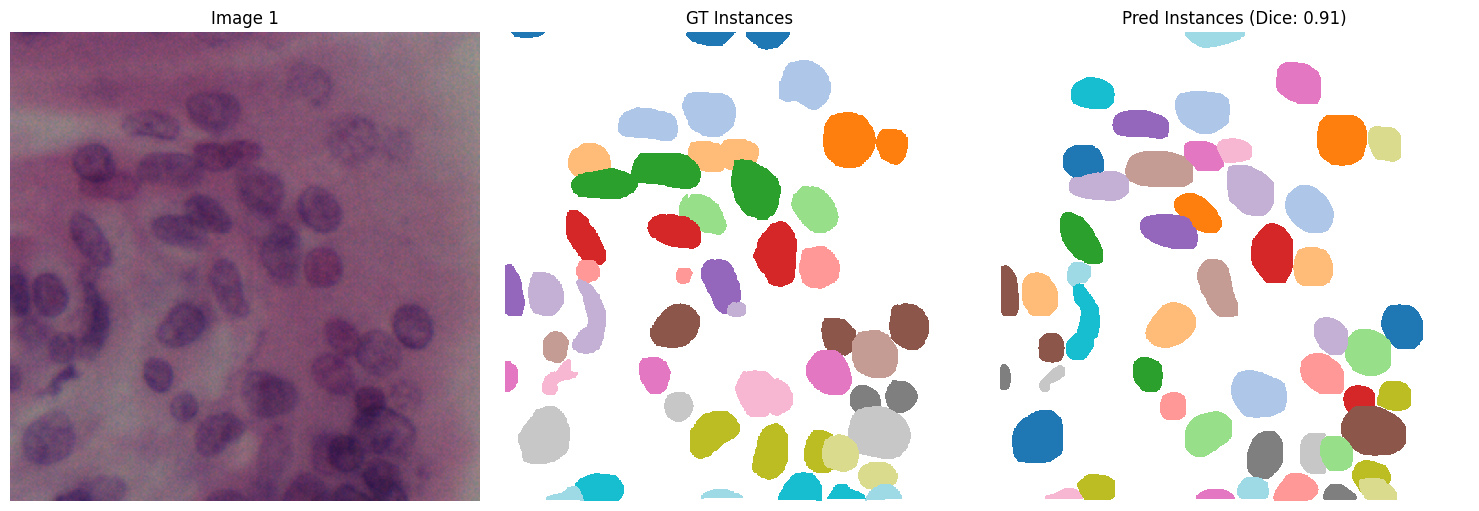

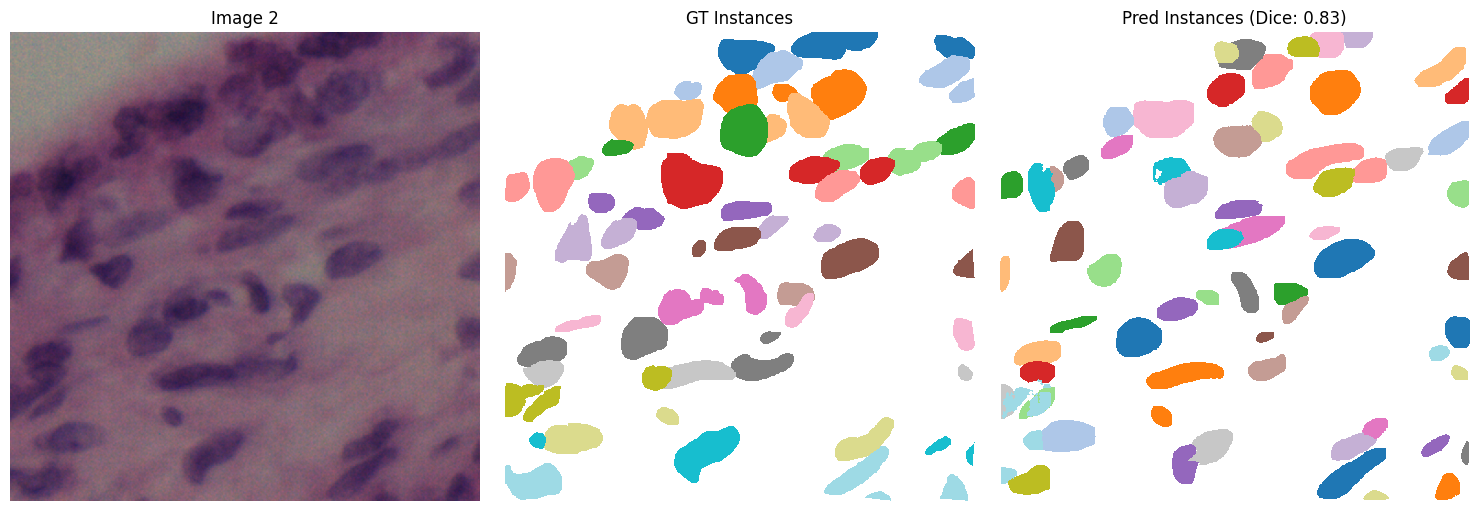

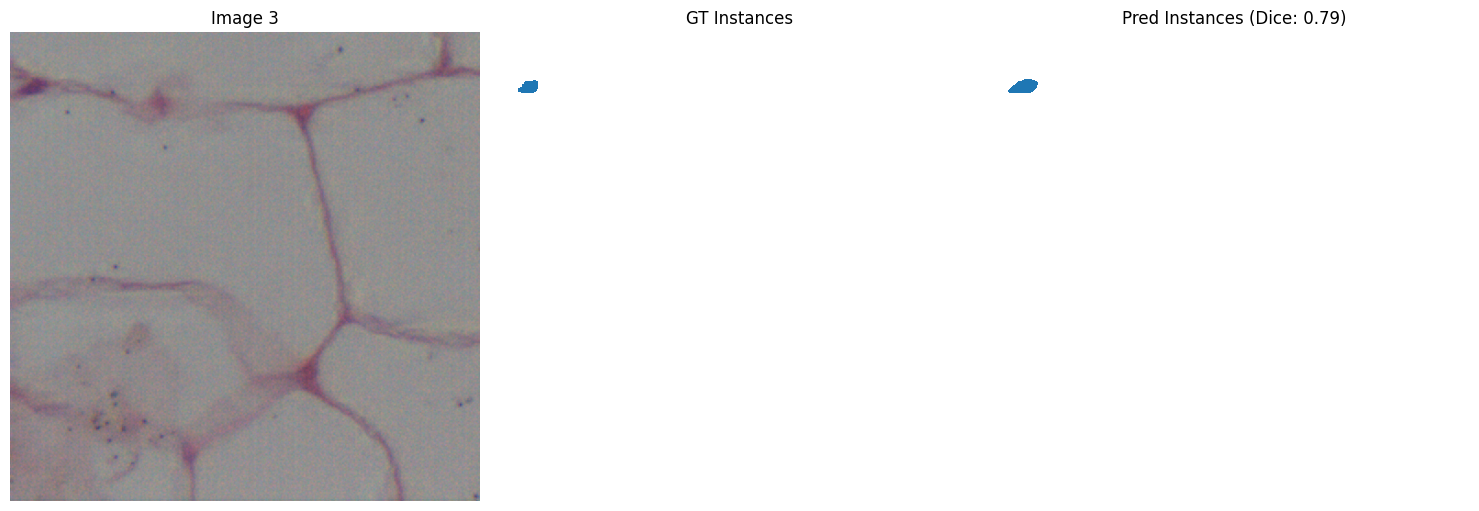

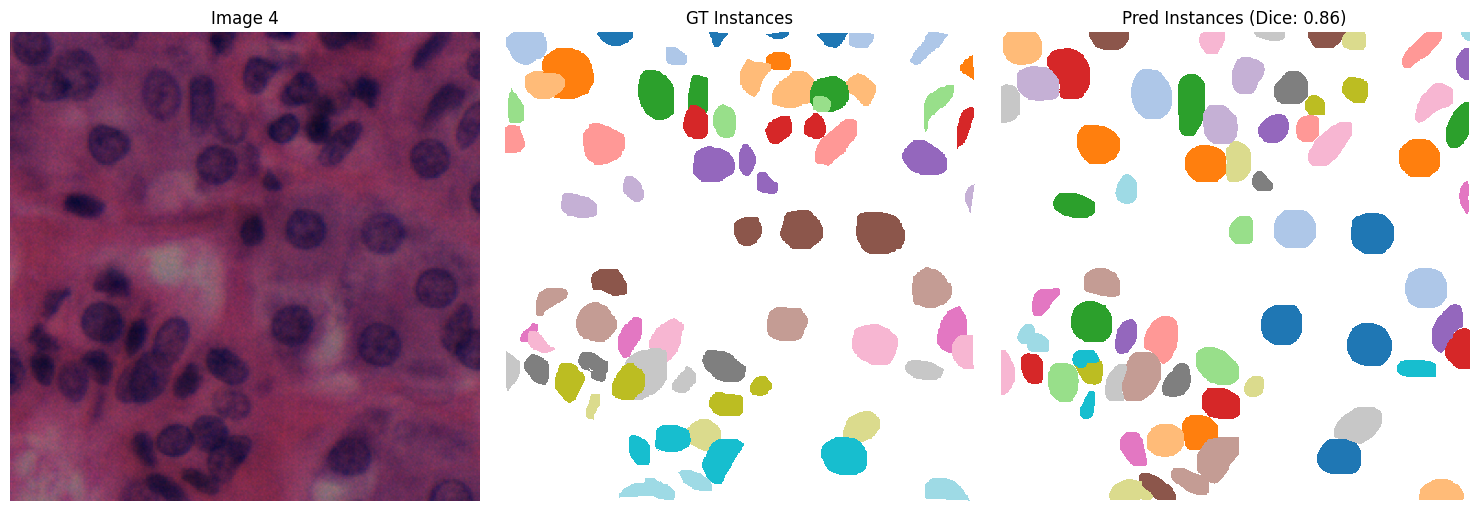

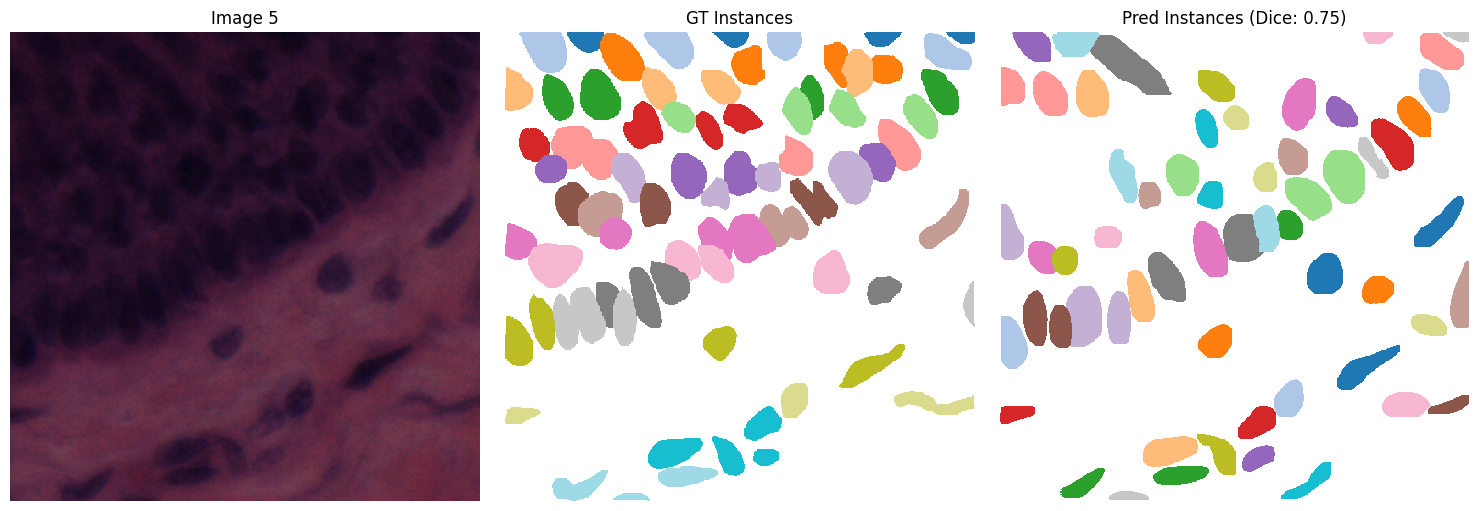


Overall Mean Dice Score (Global): 0.8082


In [27]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def compute_dice_score(pred_mask, gt_mask):
    # Calculates Global Dice (Foreground vs Background)
    pred_flat = pred_mask.flatten()
    gt_flat = gt_mask.flatten()
    intersection = np.sum(pred_flat * gt_flat)
    return (2. * intersection) / (np.sum(pred_flat) + np.sum(gt_flat) + 1e-6)

def create_instance_map(masks):
    """
    Combines N binary masks into a single 2D map where each instance 
    has a unique ID value (1, 2, 3...).
    masks: Shape [N, H, W]
    """
    if len(masks) == 0:
        return None 
        
    _, H, W = masks.shape
    instance_map = np.zeros((H, W), dtype=np.int32)
    
    # Iterate through masks and paint them with a unique ID (idx + 1)
    for idx, mask in enumerate(masks):
        instance_map[mask > 0] = idx + 1 
        
    return instance_map

dice_scores = []
num_shown = 0 
model.eval()

with torch.no_grad():
    for images, targets in val_loader:
        images_device = [img.to(device) for img in images]
        outputs = model(images_device)

        for i, out in enumerate(outputs):
            # --- 1. Process Prediction (With 20% Threshold) ---
            scores = out["scores"].cpu().numpy()
            
            # CHANGE: Filter by 20% confidence
            keep_idx = scores > 0.5
            
            # Filter the raw masks based on the score
            pred_masks_soft = out["masks"][keep_idx]  # [N_filtered, 1, H, W]

            if len(pred_masks_soft) > 0:
                pred_masks_np = pred_masks_soft.squeeze(1).cpu().numpy()
                pred_masks_binary = pred_masks_np > 0.5
                
                # A) Create Binary Map for Dice Score
                combined_binary_pred = np.max(pred_masks_binary, axis=0).astype(np.uint8)
                
                # B) Create Instance Map for Visualization
                pred_instance_map = create_instance_map(pred_masks_binary)
            else:
                # Handle case where nothing passed the threshold
                img_h, img_w = images[i].shape[-2:]
                combined_binary_pred = np.zeros((img_h, img_w), dtype=np.uint8)
                pred_instance_map = np.zeros((img_h, img_w), dtype=np.int32)

            # --- 2. Process Ground Truth ---
            gt_masks_np = targets[i]["masks"].cpu().numpy() # [N, H, W]
            
            # A) Binary GT for Dice
            if len(gt_masks_np) > 0:
                combined_binary_gt = np.max(gt_masks_np, axis=0).astype(np.uint8)
            else:
                combined_binary_gt = np.zeros_like(combined_binary_pred)
                
            # B) Instance GT for Visualization
            if len(gt_masks_np) > 0:
                gt_instance_map = create_instance_map(gt_masks_np)
            else:
                gt_instance_map = np.zeros_like(pred_instance_map)

            # --- 3. Calculate Dice (Global Semantic) ---
            d = compute_dice_score(combined_binary_pred, combined_binary_gt)
            dice_scores.append(d)
            
            # --- 4. Visualization ---
            if num_shown < 5:
                img_display = images[i].permute(1, 2, 0).numpy()
                
                fig, axes = plt.subplots(1, 3, figsize=(15, 5))
                
                # 1. Original
                axes[0].imshow(img_display)
                axes[0].set_title(f"Image {num_shown+1}")
                axes[0].axis('off')
                
                # 2. GT Instances
                gt_masked = np.ma.masked_where(gt_instance_map == 0, gt_instance_map)
                axes[1].imshow(gt_masked, cmap='tab20', alpha=1.0, interpolation='none')
                axes[1].set_title("GT Instances")
                axes[1].axis('off')
                
                # 3. Pred Instances
                pred_masked = np.ma.masked_where(pred_instance_map == 0, pred_instance_map)
                axes[2].imshow(pred_masked, cmap='tab20', alpha=1.0, interpolation='none')
                axes[2].set_title(f"Pred Instances (Dice: {d:.2f})")
                axes[2].axis('off')
                
                plt.tight_layout()
                plt.show()
                
                num_shown += 1

print(f"\nOverall Mean Dice Score (Global): {np.mean(dice_scores):.4f}")